### Importing necessay libraries

In [ ]:
import numpy as np
import scipy as sc
import pandas as pd
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import math
from scipy import signal
import control as ct

In [2]:
## For matlab environment

import matlab
import matlab.engine


## EMA using Impact hammer 
### Location of sensors and their respective channel numbers.
### CH-08 : Impact hammer

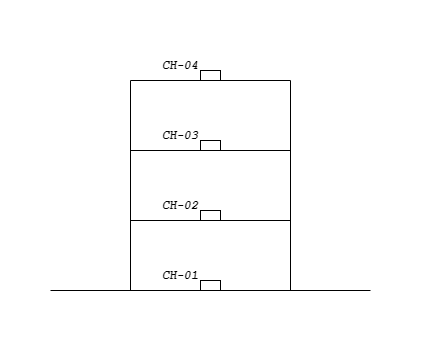

In [3]:
# First set of loading data (Impact hammer)
da_1 = pd.read_csv("imp_ham_set1_nomass.csv" ,skiprows= 14, header= None, names=["Time","First Floor", "Second Floor", "Top Floor", "Base Acceleration", "Hammer"])
da_1.head()

,Time,First Floor,Second Floor,Top Floor,Base Acceleration,Hammer
0,0.00,-1.778344,2.910366,1.3403,2.460990,3.170733
1,0.02,-2.413548,1.863738,0.3016,3.237820,2.743904
2,0.04,-1.292571,2.568262,-0.2717,4.284161,2.317074
3,0.06,-0.354560,1.513866,-0.0650,4.268307,3.231709
4,0.08,-0.575994,0.960226,-0.7566,4.658551,2.439026


## Impact Hammer Calibration

Impact hammer is a widely used instrument for Experimental Modal Analysis (EMA) of structures. It has applications mainly in aerospace and mechanical components such as turbine blades, aircraft wings, etc. For the purposes of this lab work, the steel tip impact hammer provided sufficient broadband excitation for the frequencies of interest.

Proper calibration of impact hammers is critical to ensure measurement accuracy and satisfy quality management requirements.

The following steps were employed to calibrate the impact hammer:

### Step 1
The mass of the calibration system was determined by measuring the mass of the suspended object and any supporting components. In this case, the mass of the supporting wire was neglected.

$$
m = m_{\text{object}} + m_{\text{string}}
$$

### Step 2
An accelerometer was securely placed on the mass, ensuring proper alignment.

### Step 3
An impulsive force was applied to the suspended mass using the impact hammer. The acceleration response of the mass and the corresponding voltage signal from the hammer were recorded.

### Step 4
Using the recorded acceleration data, the peak acceleration response was determined and the corresponding impact force was calculated as:

$$
F = m \, a_{\text{peak}}
$$

### Step 5
The peak voltage from the hammer signal was obtained and the calibration constant was determined as:

$$
K = \frac{F}{V}
$$

Using the voltage recording and the calculated force value, the calibration constant of the impact hammer was obtained by dividing the force by the corresponding voltage.

This calibration procedure was performed twice, and the average value was taken as the final calibration constant.

---

### Calibration Results

| **Calibration 1** |  |  | **Calibration 2** |  |  |
|---|---|---|---|---|---|
| **Parameter** | **Value** | **Unit** | **Parameter** | **Value** | **Unit** |
| Max Acceleration | 3.980121512 | m/s² | Max Acceleration | 10.18547517 | m/s² |
| Mass | 1.25 | kg | Mass | 1.25 | kg |
| Force (F) | 4.97515189 | N | Force (F) | 12.73184396 | N |
| Voltage (V) | 727.5609759 | — | Voltage (V) | 1248.414634 | — |
| Calibration Constant (K) | **0.006838124** | — | Calibration Constant (K) | **0.01019841** | — |

---

The final calibration constant was:

$$
K_{\text{final}} = 0.00852
$$

In [4]:
#Calibration constant
k = 0.00852

In [5]:
data_1 = da_1.to_numpy()
hammer_input_1 = data_1[:,[0,5]]    #in cm/sec^2
first_floor_repsonse_1 = data_1[:,[0,1]]   # in cm/sec^2
second_floor_repsonse_1 = data_1[:,[0,2]]   # in cm/sec^2
top_floor_repsonse_1 = data_1[:,[0,3]]  # in cm/sec^2 
base_response_1 = data_1[:,[0,4]] 
dt_1 = data_1[1,0] - data_1[0,0]


hammer_input_1[:,1] = hammer_input_1[:,1] * k 
first_floor_repsonse_1[:,1] = first_floor_repsonse_1[:,1] /100   # in m/sec^2
second_floor_repsonse_1[:,1] = second_floor_repsonse_1[:,1] /100  # in m/sec^2
top_floor_repsonse_1[:,1] = top_floor_repsonse_1[:,1] /100  # in m/sec^2
#print(np.max(hammer_input[:,1]))

## Plot and observe the impact/ imput excitation. It is important to check this in case of double impact.

(0.0, 1.0)

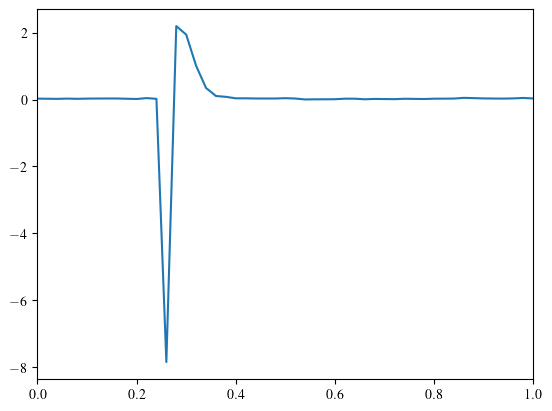

In [6]:
plt.plot(hammer_input_1[:,0], hammer_input_1[:,1])
plt.xlim(0,1)

# In this case there is a single clean impact so we can move forward with analysis.

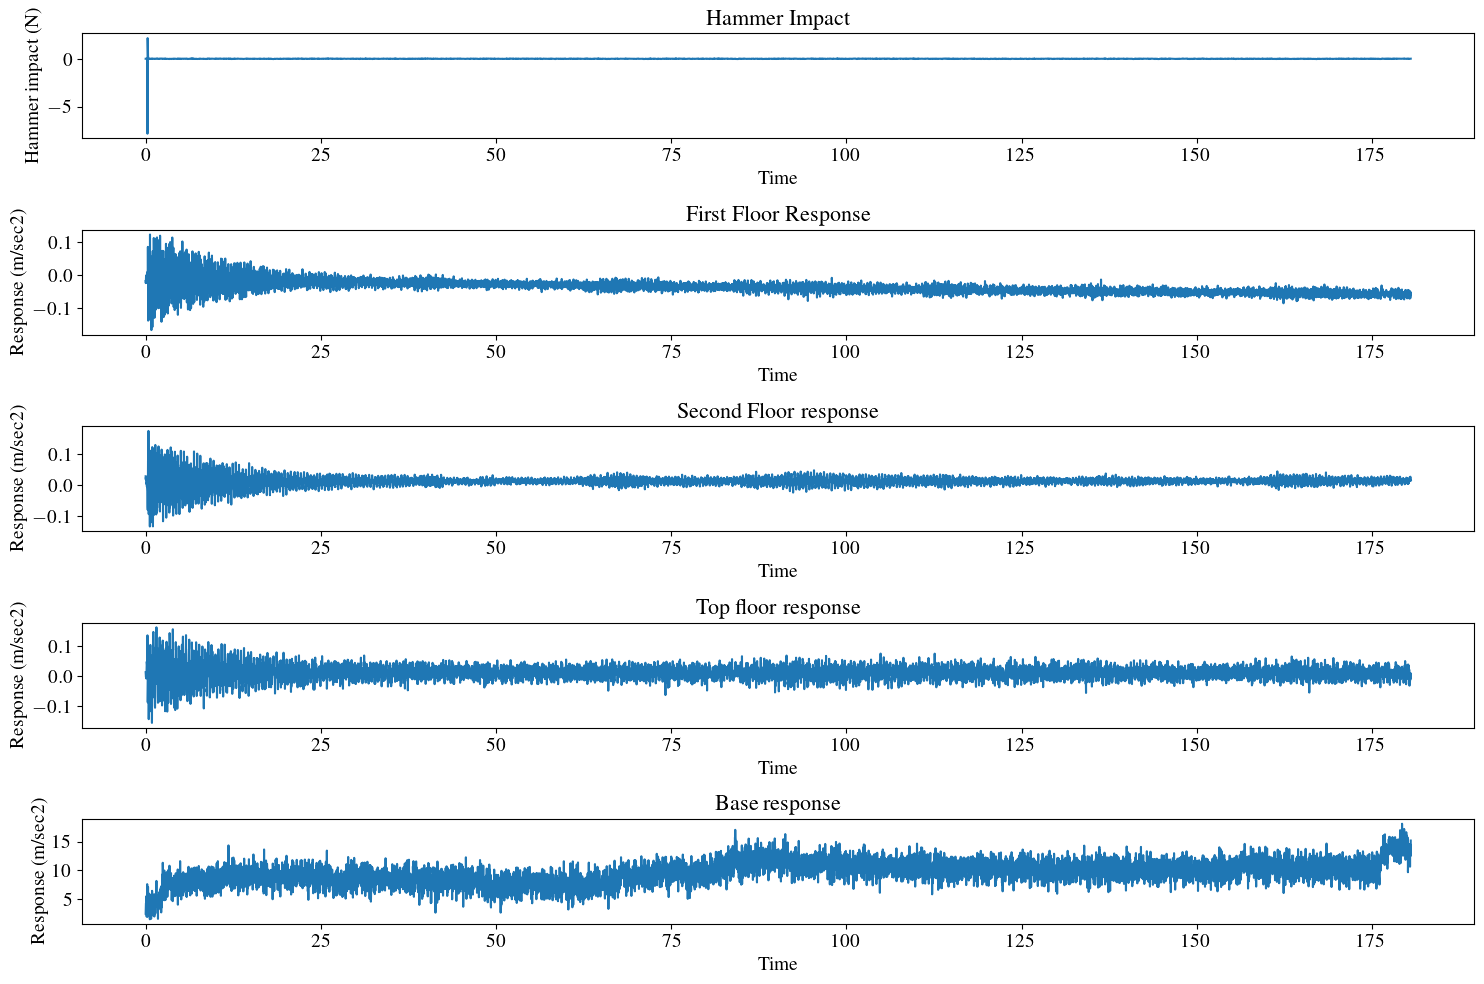

In [7]:
#########################################################################################
# Plotted to visualize the data
#########################################################################################
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5,1 , figsize = (15, 10))
#fig, (ax1, ax2) = plt.subplots(2,1 , figsize = (15, 10), sharex=True)

ax1.plot(hammer_input_1[:,0], hammer_input_1[:,1])
ax1.set_xlabel("Time", fontsize= 14 )
ax1.set_ylabel("Hammer impact (N)", fontsize= 14 )
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_title("Hammer Impact", fontsize= 16)
#ax1.set_xlim(0,100)

ax2.plot(first_floor_repsonse_1[:,0], first_floor_repsonse_1[:,1])
ax2.set_xlabel("Time", fontsize= 14 )
ax2.set_ylabel("Response (m/sec2)", fontsize= 14 )
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_title("First Floor Response", fontsize= 16)
#ax2.set_xlim(0,100)

ax3.plot(second_floor_repsonse_1[:,0], second_floor_repsonse_1[:,1])
ax3.set_xlabel("Time", fontsize= 14 )
ax3.set_ylabel("Response (m/sec2)", fontsize= 14 )
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.set_title("Second Floor response", fontsize= 16)
#ax3.set_xlim(0,100)

ax4.plot(top_floor_repsonse_1[:,0],top_floor_repsonse_1[:,1] )
ax4.set_xlabel("Time", fontsize= 14 )
ax4.set_ylabel("Response (m/sec2)", fontsize= 14 )
ax4.tick_params(axis='x', labelsize=14)
ax4.tick_params(axis='y', labelsize=14)
ax4.set_title("Top floor response", fontsize= 16)
#ax4.set_xlim(0,100)

ax5.plot(base_response_1[:,0],base_response_1[:,1] )
ax5.set_xlabel("Time", fontsize= 14 )
ax5.set_ylabel("Response (m/sec2)", fontsize= 14 )
ax5.tick_params(axis='x', labelsize=14)
ax5.tick_params(axis='y', labelsize=14)
ax5.set_title("Base response", fontsize= 16)
#ax5.set_xlim(0,100)


plt.tight_layout()
#########################################################################################


### Here, we can observe some excitation in the base of the structure. This is likely attributed to the fact that the frame is mounted on a shaker platform, which was not completely stationary during testing. Hence, we observe some movement. Now we can neglect this movement because our calculations are based on frequency domain and this unwanted shaking will not pose a problem in frequency domain.

## Lets do MODAL FRF ON THESE DATA SETS

In [8]:
# Start MATLAB engine
eng = matlab.engine.start_matlab()

### Here 1 is top floor 2 is second floor and 3 is first floor in frequecny response function calculations

In [9]:
first_floor_response_m_1 = matlab.double(first_floor_repsonse_1[:,1].tolist())
second_floor_response_m_1 = matlab.double(second_floor_repsonse_1[:,1].tolist())
top_floor_response_m_1 = matlab.double(top_floor_repsonse_1[:,1].tolist())
base_response_m_1 = matlab.double(base_response_1[:,1].tolist())
F = matlab.double(hammer_input_1[:,1].tolist())

In [ ]:
fs_mat = float(1/dt_1)

# Window = number of columns in u
window = int(first_floor_repsonse_1.shape[0])
#window = 9000
# ============================================================
# Call MATLAB modalfrf (requires Signal Processing / Modal Toolbox)
# ============================================================

H11, fr_1 = eng.modalfrf(F, first_floor_response_m_1, fs_mat, window,nargout=2)
H21, fr_1  = eng.modalfrf(F, second_floor_response_m_1, fs_mat, window, nargout=2)
H31, fr_1  = eng.modalfrf(F, top_floor_response_m_1, fs_mat, window, nargout=2)

In [51]:
eng.figure(nargout = 0)
eng.subplot(3.0,1.0,1.0,nargout = 0)
eng.plot(fr_1,eng.imag(H11),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0) 
#eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,1.0,2.0,nargout = 0)
eng.plot(fr_1,eng.imag(H21),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
#eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,1.0,3.0,nargout = 0)
eng.plot(fr_1,eng.imag(H31),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
#eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

In [29]:
# First set of loading data (Impact hammer)
da_2 = pd.read_csv("imp_ham_set2_nomass.csv" ,skiprows= 14, header= None, names=["Time","First Floor", "Second Floor", "Top Floor", "Base Acceleration", "Hammer"])


data_2 = da_2.to_numpy()
hammer_input_2 = data_2[:,[0,5]]    #in cm/sec^2
first_floor_repsonse_2 = data_2[:,[0,1]]   # in cm/sec^2
second_floor_repsonse_2 = data_2[:,[0,2]]   # in cm/sec^2
top_floor_repsonse_2 = data_2[:,[0,3]]  # in cm/sec^2 
base_response_2 = data_2[:,[0,4]] 
dt_2 = data_2[1,0] - data_2[0,0]


hammer_input_2[:,1] = hammer_input_2[:,1] * k 
first_floor_repsonse_2[:,1] = first_floor_repsonse_2[:,1] /100   # in m/sec^2
second_floor_repsonse_2[:,1] = second_floor_repsonse_2[:,1] /100  # in m/sec^2
top_floor_repsonse_2[:,1] = top_floor_repsonse_2[:,1] /100  # in m/sec^2

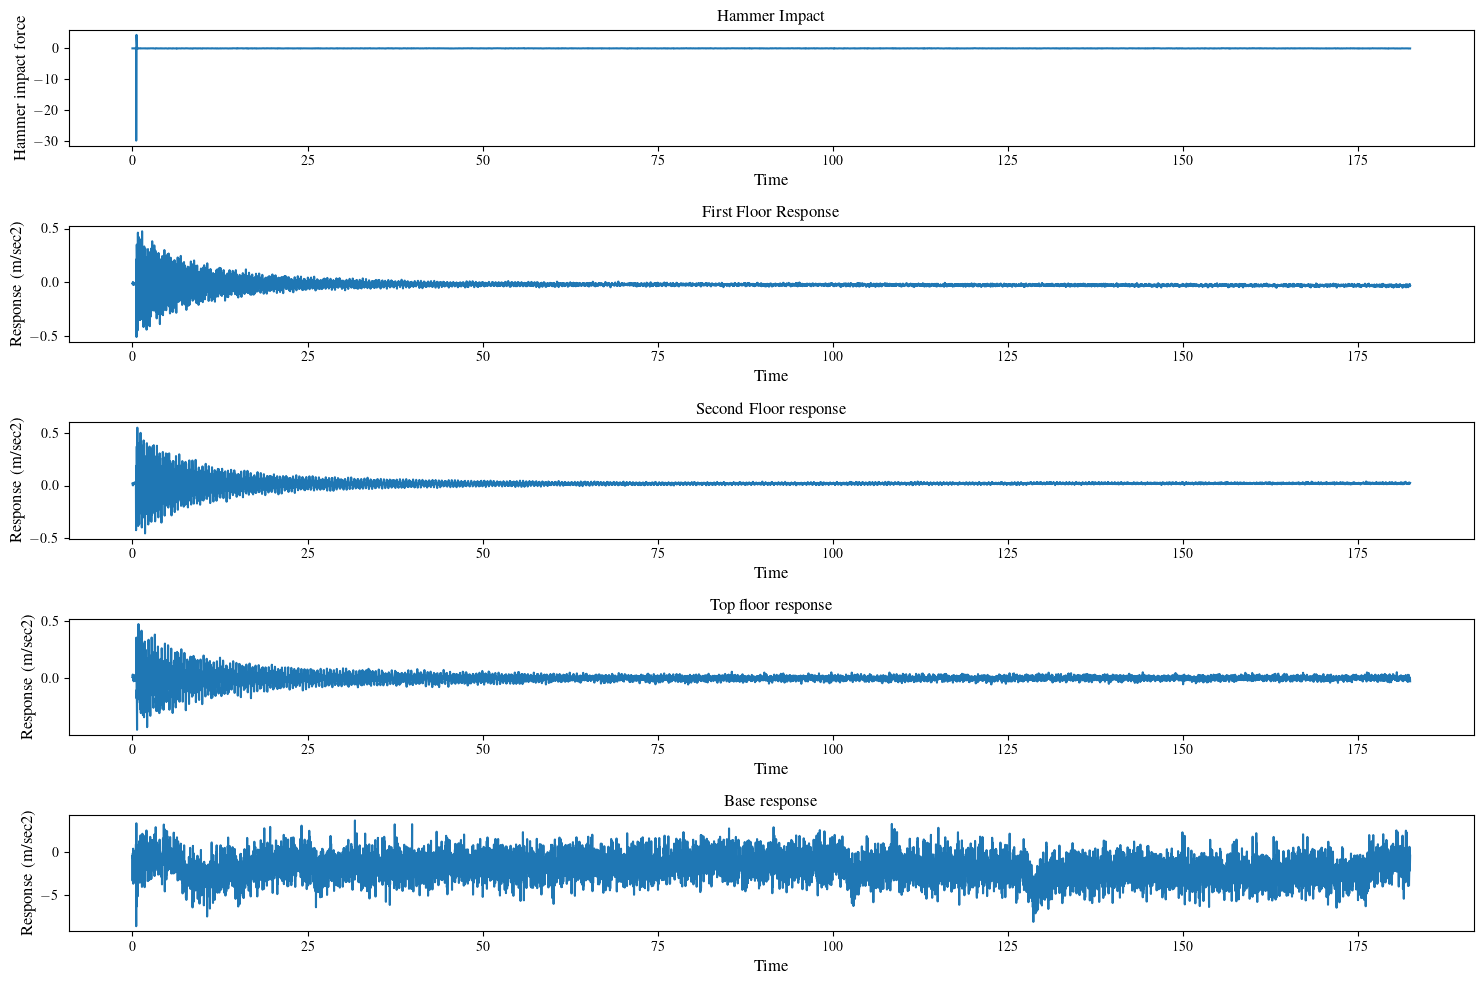

In [30]:
#########################################################################################
# Plotted to visualize the data
#########################################################################################
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5,1 , figsize = (15, 10))
#fig, (ax1, ax2) = plt.subplots(2,1 , figsize = (15, 10), sharex=True)

ax1.plot(hammer_input_2[:,0], hammer_input_2[:,1])
ax1.set_xlabel("Time")
ax1.set_ylabel("Hammer impact force")
ax1.set_title("Hammer Impact")
#ax1.set_xlim(0,100)

ax2.plot(first_floor_repsonse_2[:,0], first_floor_repsonse_2[:,1])
ax2.set_xlabel("Time")
ax2.set_ylabel("Response (m/sec2)")
ax2.set_title("First Floor Response")
#ax2.set_xlim(0,100)

ax3.plot(second_floor_repsonse_2[:,0], second_floor_repsonse_2[:,1])
ax3.set_xlabel("Time")
ax3.set_ylabel("Response (m/sec2)")
ax3.set_title("Second Floor response")
#ax3.set_xlim(0,100)

ax4.plot(top_floor_repsonse_2[:,0],top_floor_repsonse_2[:,1] )
ax4.set_xlabel("Time")
ax4.set_ylabel("Response (m/sec2)")
ax4.set_title("Top floor response")
#ax4.set_xlim(0,100)

ax5.plot(base_response_2[:,0],base_response_2[:,1] )
ax5.set_xlabel("Time")
ax5.set_ylabel("Response (m/sec2)")
ax5.set_title("Base response")
#ax5.set_xlim(0,100)


plt.tight_layout()
#########################################################################################


In [31]:
first_floor_response_m_2 = matlab.double(first_floor_repsonse_2[:,1].tolist())
second_floor_response_m_2 = matlab.double(second_floor_repsonse_2[:,1].tolist())
top_floor_response_m_2 = matlab.double(top_floor_repsonse_2[:,1].tolist())
base_response_m_2 = matlab.double(base_response_2[:,1].tolist())
F_2 = matlab.double(hammer_input_2[:,1].tolist())

In [32]:
fs_mat_2 = float(1/dt_2)

# Window = number of columns in u
window_2 = int(first_floor_repsonse_2.shape[0])
#window = 9000
# ============================================================
# Call MATLAB modalfrf (requires Signal Processing / Modal Toolbox)
# ============================================================
H12, fr_2 = eng.modalfrf(F_2, first_floor_response_m_2, fs_mat_2, window_2, nargout=2)
H22, fr_2  = eng.modalfrf(F_2, second_floor_response_m_2, fs_mat_2, window_2, nargout=2)
H32, fr_2  = eng.modalfrf(F_2, top_floor_response_m_2, fs_mat_2, window_2, nargout=2)

In [42]:
eng.figure(nargout = 0)
eng.subplot(3.0,1.0,1.0,nargout = 0)
eng.plot(fr_2,eng.imag(H12),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0) 
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,1.0,2.0,nargout = 0)
eng.plot(fr_2,eng.imag(H22),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,1.0,3.0,nargout = 0)
eng.plot(fr_2,eng.imag(H32),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

## Set 3 No mass   : Impact at third dof recorded at all dof

In [35]:
# First set of loading data (Impact hammer)
da_3 = pd.read_csv("imp_ham_set3_no_mass.csv" ,skiprows= 14, header= None, names=["Time","First Floor", "Second Floor", "Top Floor", "Base Acceleration", "Hammer"])


data_3 = da_3.to_numpy()
hammer_input_3 = data_3[:,[0,5]]    #in cm/sec^2
first_floor_repsonse_3 = data_3[:,[0,1]]   # in cm/sec^2
second_floor_repsonse_3 = data_3[:,[0,2]]   # in cm/sec^2
top_floor_repsonse_3 = data_3[:,[0,3]]  # in cm/sec^2 
base_response_3 = data_3[:,[0,4]] 
dt_3 = data_3[1,0] - data_3[0,0]


hammer_input_3[:,1] = hammer_input_3[:,1] * k 
first_floor_repsonse_3[:,1] = first_floor_repsonse_3[:,1] /100   # in m/sec^2
second_floor_repsonse_3[:,1] = second_floor_repsonse_3[:,1] /100  # in m/sec^2
top_floor_repsonse_3[:,1] = top_floor_repsonse_3[:,1] /100  # in m/sec^2

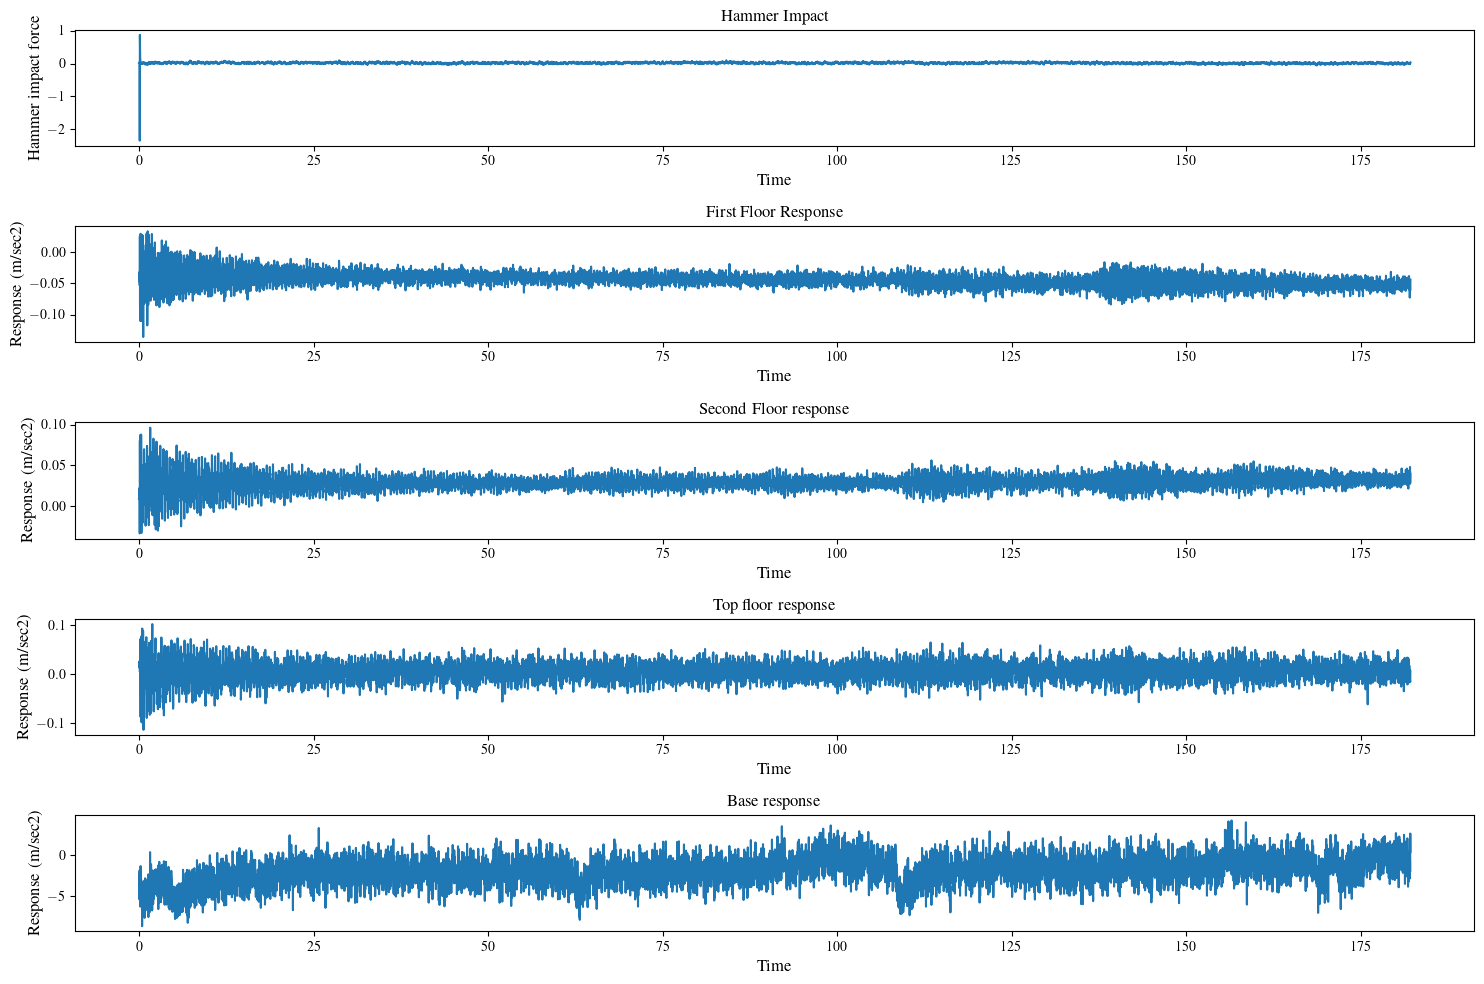

In [36]:
#########################################################################################
# Plotted to visualize the data
#########################################################################################
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5,1 , figsize = (15, 10))
#fig, (ax1, ax2) = plt.subplots(2,1 , figsize = (15, 10), sharex=True)

ax1.plot(hammer_input_3[:,0], hammer_input_3[:,1])
ax1.set_xlabel("Time")
ax1.set_ylabel("Hammer impact force")
ax1.set_title("Hammer Impact")
#ax1.set_xlim(0,100)

ax2.plot(first_floor_repsonse_3[:,0], first_floor_repsonse_3[:,1])
ax2.set_xlabel("Time")
ax2.set_ylabel("Response (m/sec2)")
ax2.set_title("First Floor Response")
#ax2.set_xlim(0,100)

ax3.plot(second_floor_repsonse_3[:,0], second_floor_repsonse_3[:,1])
ax3.set_xlabel("Time")
ax3.set_ylabel("Response (m/sec2)")
ax3.set_title("Second Floor response")
#ax3.set_xlim(0,100)

ax4.plot(top_floor_repsonse_3[:,0],top_floor_repsonse_3[:,1] )
ax4.set_xlabel("Time")
ax4.set_ylabel("Response (m/sec2)")
ax4.set_title("Top floor response")
#ax4.set_xlim(0,100)

ax5.plot(base_response_3[:,0],base_response_3[:,1] )
ax5.set_xlabel("Time")
ax5.set_ylabel("Response (m/sec2)")
ax5.set_title("Base response")
#ax5.set_xlim(0,100)


plt.tight_layout()
#########################################################################################


In [78]:
first_floor_response_m_3 = matlab.double(first_floor_repsonse_3[:,1].tolist())
second_floor_response_m_3 = matlab.double(second_floor_repsonse_3[:,1].tolist())
top_floor_response_m_3 = matlab.double(top_floor_repsonse_3[:,1].tolist())
base_response_m_3 = matlab.double(base_response_3[:,1].tolist())
F_3 = matlab.double(hammer_input_3[:,1].tolist())

In [79]:
fs_mat_3 = float(1/dt_3)

# Window = number of columns in u
window_3 = int(first_floor_repsonse_3.shape[0])
#window = 9000
# ============================================================
# Call MATLAB modalfrf (requires Signal Processing / Modal Toolbox)
# ============================================================
H13, fr_3 = eng.modalfrf(F_3, first_floor_response_m_3, fs_mat_3, window_3, nargout=2)
H23, fr_3 = eng.modalfrf(F_3, second_floor_response_m_3, fs_mat_3, window_3, nargout=2)
H33, fr_3  = eng.modalfrf(F_3, top_floor_response_m_3, fs_mat_3, window_3, nargout=2)

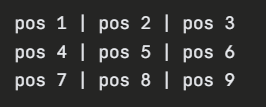

## Imaginary part

In [62]:
eng.figure(nargout = 0)
eng.subplot(3.0,3.0,1.0,nargout = 0)
eng.plot(fr_1,eng.imag(H11),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.title('H11') 
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,3.0, 4.0,nargout = 0)
eng.plot(fr_1,eng.imag(H21),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.title('H21')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,3.0,7.0,nargout = 0)
eng.plot(fr_1,eng.imag(H31),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.title('H31')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

#################################################################################


eng.subplot(3.0,3.0,2.0,nargout = 0)
eng.plot(fr_2,eng.imag(H12),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0) 
eng.title('H12')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,3.0, 5.0,nargout = 0)
eng.plot(fr_2,eng.imag(H22),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.title('H22')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,3.0,8.0,nargout = 0)
eng.plot(fr_2,eng.imag(H32),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.title('H32')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

#################################################################################


eng.subplot(3.0,3.0,3.0,nargout = 0)
eng.plot(fr_3,eng.imag(H13),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0) 
eng.title('H13')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,3.0, 6.0,nargout = 0)
eng.plot(fr_3,eng.imag(H23),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.title('H23')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

eng.subplot(3.0,3.0, 9.0,nargout = 0)
eng.plot(fr_3,eng.imag(H33),nargout = 0);
eng.xlabel('Frequency',nargout = 0)
eng.ylabel('Amplitude',nargout = 0)
eng.title('H33')
eng.xlim(matlab.double([0.0, 0.15]), nargout=0)

## Real part

In [46]:
eng.figure(nargout=0)

eng.subplot(3.0, 3.0, 1.0, nargout=0)
eng.plot(fr_1, eng.mag2db(eng.abs(H11)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H11')
#eng.xlim(matlab.double([0.3, 12]), nargout=0)

eng.subplot(3.0, 3.0, 4.0, nargout=0)
eng.plot(fr_1, eng.mag2db(eng.abs(H21)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H21')
#eng.xlim(matlab.double([0.3, 12]), nargout=0)

eng.subplot(3.0, 3.0, 7.0, nargout=0)
eng.plot(fr_1, eng.mag2db(eng.abs(H31)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H31')


#################################################################################


eng.subplot(3.0, 3.0, 2.0, nargout=0)
eng.plot(fr_2, eng.mag2db(eng.abs(H12)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H12')
#eng.xlim(matlab.double([0.3, 12]), nargout=0)

eng.subplot(3.0, 3.0, 5.0, nargout=0)
eng.plot(fr_2, eng.mag2db(eng.abs(H22)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H22')
#eng.xlim(matlab.double([0.3, 12]), nargout=0)

eng.subplot(3.0, 3.0, 8.0, nargout=0)
eng.plot(fr_2, eng.mag2db(eng.abs(H32)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H32')

#################################################################################

eng.subplot(3.0, 3.0, 3.0, nargout=0)
eng.plot(fr_3, eng.mag2db(eng.abs(H13)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H13')
#eng.xlim(matlab.double([0.3, 12]), nargout=0)

eng.subplot(3.0, 3.0, 6.0, nargout=0)
eng.plot(fr_3, eng.mag2db(eng.abs(H23)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H23')
#eng.xlim(matlab.double([0.3, 12]), nargout=0)

eng.subplot(3.0, 3.0, 9.0, nargout=0)
eng.plot(fr_3, eng.mag2db(eng.abs(H33)), nargout=0)
eng.xlabel('Frequency', nargout=0)
eng.ylabel('Amplitude', nargout=0)
eng.title('H33')